# Experiment 3: Property-driven multiclass trainin

In [1]:
import os
import sys
import copy
import joblib

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from utils.models import build_model
from utils.preprocessing import (
    PROPERTY_BOOLEAN_FEATURES,
    MODEL_CATEGORICAL_FEATURES,
    MODEL_NUMERIC_FEATURES,
    ENGINEERED_FEATURES,
    PORTSCAN_FEATURES,
    filter_labels,
)
from utils.evaluation import evaluate_model, load_and_evaluate_model

from property_factory import build_properties
import property_driven_ml.logics as pml_logics

from datetime import date
from specs import ATTACK_SPECS

from utils.preprocessing import PROPERTY_BOOLEAN_FEATURES
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
df_cicids2017_train = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_cicids2017_test = pd.read_csv("../data/cicids2017_test.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_train = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_test = pd.read_csv("../data/ciciot2023_test.tsv", on_bad_lines="skip", delimiter="\t")

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_21108\2615196177.py:3: DtypeWarning: Columns (0: duration, 1: orig_bytes, 2: resp_bytes) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ciciot2023_train = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")


## Add property features

### Define labels and filter dataset

In [3]:
PROPERTY_MODEL_FEATURES = (
    MODEL_CATEGORICAL_FEATURES
    + MODEL_NUMERIC_FEATURES
    + ENGINEERED_FEATURES 
    + PORTSCAN_FEATURES
)

PROPERTY_FEATURES = PROPERTY_MODEL_FEATURES + PROPERTY_BOOLEAN_FEATURES
PROPERTY_FEATURES_WITH_LABEL = PROPERTY_FEATURES + ["label"]

In [4]:
def compute_time_elapsed(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["id.orig_h", "id.resp_h", "ts"]).reset_index(drop=True)

    df["time_elapsed"] = (
        df.groupby(["id.orig_h", "id.resp_h"])["ts"]
        .diff()
        .fillna(999999.0)
    )

    return df

def compute_valid_tcp_handshake(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    proto_ok =  df["proto"].eq("tcp")
    history_ok = df["history"].str.contains(r"S.*h.*A", regex=True, na=False)

    df["valid_tcp_handshake"] = (proto_ok & history_ok).astype(int)
    return df

def compute_valid_http_conn(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    proto_ok =  df["proto"].eq("tcp")
    port_http = df["id.resp_p"].isin([80, 8080, 8000])
    port_https = df["id.resp_p"].isin([443, 8443])
    service_http = df["service"].str.lower().eq("http")
    service_https = df["service"].str.lower().eq("https")
    service_ssl = df["service"].str.lower().eq("ssl")
    has_data = df["history"].str.contains(r"D", regex=True, na=False)

    df["valid_http_conn"] = (
        proto_ok &
        ((port_http & service_http) | (port_https & (service_https | service_ssl))) 
        & has_data
    ).astype(int)
    return df

In [5]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    numeric_cols = [
        "ts",
        "duration",
        "orig_bytes",
        "resp_bytes",
        "missed_bytes",
        "orig_pkts",
        "orig_ip_bytes",
        "resp_pkts",
        "resp_ip_bytes",
        "id.resp_p",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    existing_numeric = [c for c in numeric_cols if c in df.columns]
    if existing_numeric:
        df[existing_numeric] = df[existing_numeric].replace([np.inf, -np.inf], np.nan)
        df[existing_numeric] = df[existing_numeric].fillna(0.0)

    df = compute_time_elapsed(df)

    duration_safe = df["duration"].copy()
    duration_safe = duration_safe.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    duration_safe = duration_safe.mask(duration_safe <= 0, 1e-6)

    df["orig_pkt_rate"] = df["orig_pkts"] / duration_safe if "orig_pkts" in df.columns else 0.0
    df["orig_byte_rate"] = df["orig_bytes"] / duration_safe if "orig_bytes" in df.columns else 0.0
    df["flood_rate"] = df["orig_bytes"] / duration_safe if "orig_bytes" in df.columns else 0.0
    df["pkt_asymmetry"] = df["orig_pkts"] / (df["resp_pkts"] + 1.0)
    df["byte_asymmetry"] = df["orig_bytes"] / (df["resp_bytes"] + 1.0)

    for col in ENGINEERED_FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return df

def add_portscan_attack_features(df: pd.DataFrame, window_seconds: float = 5.0) -> pd.DataFrame:
    df = df.copy()

    df["window_id"] = (df["ts"] // window_seconds).astype(int)
    group_cols = ["id.orig_h", "window_id"]

    agg = df.groupby(group_cols).agg(
        uniq_dst_ports=("id.resp_p", "nunique"),
        total_orig_pkts=("orig_pkts", "sum"),
        scan_duration=("duration", "max"),
        total_flows=("id.orig_h", "size"),
    ).reset_index()

    FAILED_STATES = {"S0", "REJ", "RSTO", "RSTR", "RSTOS0", "RSTRH", "SH", "SHR"}
    df["is_failed_conn"] = df["conn_state"].astype(str).isin(FAILED_STATES).astype(int)

    fail_agg = df.groupby(group_cols).agg(
        failed_flows=("is_failed_conn", "sum"),
    ).reset_index()

    agg = agg.merge(fail_agg, on=group_cols, how="left")
    agg["failed_flows"] = agg["failed_flows"].fillna(0.0)

    agg["pkts_per_port"] = agg["total_orig_pkts"] / agg["uniq_dst_ports"]
    agg["fail_ratio"] = agg["failed_flows"] / agg["total_flows"]

    df = df.merge(
        agg[
            [
                "id.orig_h",
                "window_id",
                "uniq_dst_ports",
                "pkts_per_port",
                "scan_duration",
                "fail_ratio",
            ]
        ],
        on=["id.orig_h", "window_id"],
        how="left",
    )

    for col in ["uniq_dst_ports", "pkts_per_port", "scan_duration", "fail_ratio"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    return df

In [6]:
def add_property_boolean_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = add_engineered_features(df)
    df = compute_valid_tcp_handshake(df)
    df = compute_valid_http_conn(df)
    df = add_portscan_attack_features(df)

    df["is_tcp"] = df["proto"].astype(str).str.lower().eq("tcp").astype(int)

    valid_input_cols = [
        "duration",
        "orig_bytes",
        "resp_bytes",
        "orig_pkts",
        "orig_pkt_rate",
        "time_elapsed",
        "flood_rate",
    ]

    df["valid_input"] = np.isfinite(df[valid_input_cols]).all(axis=1).astype(int)

    df["valid_duration"] = (
        (df["duration"] >= ATTACK_SPECS["dos_http_flood"]["valid_duration_min"])
        & (df["duration"] <= ATTACK_SPECS["dos_http_flood"]["valid_duration_max"])
    ).astype(int)

    avg_orig_pkt_size = df["orig_bytes"] / np.maximum(df["orig_pkts"], 1.0)

    df["valid_packet_size"] = (
        (df["orig_pkts"] >= ATTACK_SPECS["validity"]["valid_packet_size_min_pkts"])
        & (avg_orig_pkt_size >= ATTACK_SPECS["validity"]["valid_packet_size_min_avg_bytes"])
        & (df["orig_bytes"] >= ATTACK_SPECS["validity"]["valid_packet_size_min_total_bytes"])
    ).astype(int)

    df["valid_iat"] = (
        df["orig_pkt_rate"] <= ATTACK_SPECS["dos_http_flood"]["valid_iat_max_pkt_rate"]
    ).astype(int)

    df["dos_http_mal_time_elapsed"] = (
        df["time_elapsed"] <= ATTACK_SPECS["dos_http_flood"]["mal_time_elapsed_max"]
    ).astype(int)

    df["dos_http_mal_flood_rate"] = (
        df["flood_rate"] >= ATTACK_SPECS["dos_http_flood"]["mal_flood_rate_min"]
    ).astype(int)

    df["portscan_many_ports"] = (
        df["uniq_dst_ports"] >= ATTACK_SPECS["portscan"]["many_ports_min"]
    ).astype(int)

    df["portscan_few_pkts_per_port"] = (
        df["pkts_per_port"] <= ATTACK_SPECS["portscan"]["few_pkts_per_port_max"]
    ).astype(int)

    df["portscan_short_duration"] = (
        df["scan_duration"] <= ATTACK_SPECS["portscan"]["short_scan_duration_max"]
    ).astype(int)

    df["portscan_high_fail_ratio"] = (
        df["fail_ratio"] >= ATTACK_SPECS["portscan"]["high_fail_ratio_min"]
    ).astype(int)

    return df

### TRAINING Functions

In [7]:
def print_dataset_info(dataset_name, df_train):
    print("\n" + "=" * 70)
    print(f"TRAINING PROPERTY MODELS ON: {dataset_name.upper()}")
    print("=" * 70)
    print("Train shape:", df_train.shape)
    print(df_train["label"].value_counts())
    print("Model features:", len(PROPERTY_MODEL_FEATURES))
    print("Property features:", len(PROPERTY_FEATURES))

In [8]:
def fit_property_preprocessor(X_train: pd.DataFrame, X_test: pd.DataFrame):
    X_train = X_train[PROPERTY_FEATURES].copy()
    X_test = X_test[PROPERTY_FEATURES].copy()

    ordinal_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )

    X_train[MODEL_CATEGORICAL_FEATURES] = ordinal_encoder.fit_transform(
        X_train[MODEL_CATEGORICAL_FEATURES]
    )

    X_test[MODEL_CATEGORICAL_FEATURES] = ordinal_encoder.transform(
        X_test[MODEL_CATEGORICAL_FEATURES]
    )

    continuous_cols = MODEL_NUMERIC_FEATURES + ENGINEERED_FEATURES + PORTSCAN_FEATURES
    binary_cols = PROPERTY_BOOLEAN_FEATURES

    X_train[continuous_cols] = X_train[continuous_cols].apply(pd.to_numeric, errors="coerce")
    X_test[continuous_cols] = X_test[continuous_cols].apply(pd.to_numeric, errors="coerce")

    X_train[continuous_cols] = (
        X_train[continuous_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    X_test[continuous_cols] = (
        X_test[continuous_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    X_train[binary_cols] = (
        X_train[binary_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(int)
    )

    X_test[binary_cols] = (
        X_test[binary_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .astype(int)
    )

    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[PROPERTY_MODEL_FEATURES] = scaler.fit_transform(
        X_train[PROPERTY_MODEL_FEATURES]
    )

    X_test_scaled[PROPERTY_MODEL_FEATURES] = scaler.transform(
        X_test[PROPERTY_MODEL_FEATURES]
    )

    X_train_scaled[binary_cols] = X_train[binary_cols].values
    X_test_scaled[binary_cols] = X_test[binary_cols].values

    return (
        X_train_scaled[PROPERTY_MODEL_FEATURES].values.astype(np.float32),
        X_test_scaled[PROPERTY_MODEL_FEATURES].values.astype(np.float32),
        X_train_scaled[PROPERTY_FEATURES].values.astype(np.float32),
        X_test_scaled[PROPERTY_FEATURES].values.astype(np.float32),
        ordinal_encoder,
        scaler,
    )

In [9]:
def prepare_property_arrays(df_train, df_test):
    X_train = df_train[PROPERTY_FEATURES]
    X_test = df_test[PROPERTY_FEATURES]
    y_train = df_train["label"]
    y_test = df_test["label"]

    (
        X_train_model_scaled,
        X_test_model_scaled,
        X_train_property_scaled,
        X_test_property_scaled,
        ordinal_encoder,
        scaler,
    ) = fit_property_preprocessor(X_train, X_test)

    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train)
    y_test_enc = label_encoder.transform(y_test)

    return {
        "X_train_model": X_train_model_scaled,
        "X_test_model": X_test_model_scaled,
        "X_train_property": X_train_property_scaled,
        "X_test_property": X_test_property_scaled,
        "y_train": y_train_enc,
        "y_test": y_test_enc,
        "y_test_raw": y_test,
        "ordinal_encoder": ordinal_encoder,
        "scaler": scaler,
        "label_encoder": label_encoder,
    }

In [10]:
def create_property_dataloaders(arrays, batch_size=10):
    (
        X_train_model_part,
        X_val_model_part,
        X_train_property_part,
        X_val_property_part,
        y_train_part,
        y_val_part,
    ) = train_test_split(
        arrays["X_train_model"],
        arrays["X_train_property"],
        arrays["y_train"],
        test_size=0.15,
        random_state=42,
        stratify=arrays["y_train"],
    )

    X_train_model_tensor = torch.tensor(X_train_model_part, dtype=torch.float32).unsqueeze(1)
    X_val_model_tensor = torch.tensor(X_val_model_part, dtype=torch.float32).unsqueeze(1)
    X_test_model_tensor = torch.tensor(arrays["X_test_model"], dtype=torch.float32).unsqueeze(1)

    X_train_property_tensor = torch.tensor(X_train_property_part, dtype=torch.float32).unsqueeze(1)
    X_val_property_tensor = torch.tensor(X_val_property_part, dtype=torch.float32).unsqueeze(1)
    X_test_property_tensor = torch.tensor(arrays["X_test_property"], dtype=torch.float32).unsqueeze(1)

    y_train_tensor = torch.tensor(y_train_part, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val_part, dtype=torch.long)
    y_test_tensor = torch.tensor(arrays["y_test"], dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_train_model_tensor, X_train_property_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        TensorDataset(X_val_model_tensor, X_val_property_tensor, y_val_tensor),
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        TensorDataset(X_test_model_tensor, X_test_property_tensor, y_test_tensor),
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader

In [11]:
def aggregate_stats(stats_dict, prefix=""):
    return {
        f"{prefix}{k}": float(np.mean(v))
        for k, v in stats_dict.items()
    }

In [12]:
def run_property_epoch(
    model,
    loader,
    criterion,
    properties,
    device,
    lambda_prop,
    optimizer=None,
):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    pred_losses = []
    prop_losses = []
    total_losses = []
    sats = []
    stats = {}

    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for x_model_batch, x_property_batch, y_batch in loader:
            x_model_batch = x_model_batch.to(device)
            x_property_batch = x_property_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_model_batch)
            pred_loss = criterion(logits, y_batch)

            prop_loss, prop_sat, prop_stats = properties.compute_loss(
                model,
                x_property_batch,
            )

            total_loss = pred_loss + lambda_prop * prop_loss

            if is_training:
                optimizer.zero_grad()
                total_loss.backward()
                optimizer.step()

            pred_losses.append(pred_loss.item())
            prop_losses.append(prop_loss.item())
            total_losses.append(total_loss.item())
            sats.append(prop_sat.item())

            for k, v in prop_stats.items():
                stats.setdefault(k, []).append(v)

    return {
        "pred_loss": float(np.mean(pred_losses)),
        "prop_loss": float(np.mean(prop_losses)),
        "total_loss": float(np.mean(total_losses)),
        "property_sat": float(np.mean(sats)),
        "stats": aggregate_stats(stats),
    }

In [13]:
def print_epoch_summary(epoch, train_metrics, val_metrics):
    print(
        f"Epoch {epoch:02d} | "
        f"train_pred_loss={train_metrics['pred_loss']:.4f} | "
        f"train_prop_loss={train_metrics['prop_loss']:.4f} | "
        f"train_total_loss={train_metrics['total_loss']:.4f} | "
        f"train_property_sat={train_metrics['property_sat']:.4f} | "
        f"val_pred_loss={val_metrics['pred_loss']:.4f} | "
        f"val_prop_loss={val_metrics['prop_loss']:.4f} | "
        f"val_total_loss={val_metrics['total_loss']:.4f} | "
        f"val_property_sat={val_metrics['property_sat']:.4f}"
    )

    print(
        "Train property stats | "
        + ", ".join(f"{k}={v:.4f}" for k, v in train_metrics["stats"].items())
    )

    print(
        "Val property stats | "
        + ", ".join(f"{k}={v:.4f}" for k, v in val_metrics["stats"].items())
    )

In [14]:
def train_property_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    properties,
    device,
    lambda_prop,
    num_epochs,
):
    history = []

    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        train_metrics = run_property_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            properties=properties,
            device=device,
            optimizer=optimizer,
            lambda_prop=lambda_prop,
        )

        val_metrics = run_property_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            properties=properties,
            device=device,
            optimizer=None,
            lambda_prop=lambda_prop,
        )

        row = {
            "epoch": epoch,
            "train_pred_loss": train_metrics["pred_loss"],
            "train_prop_loss": train_metrics["prop_loss"],
            "train_total_loss": train_metrics["total_loss"],
            "train_property_sat": train_metrics["property_sat"],
            "val_pred_loss": val_metrics["pred_loss"],
            "val_prop_loss": val_metrics["prop_loss"],
            "val_total_loss": val_metrics["total_loss"],
            "val_property_sat": val_metrics["property_sat"],
            **train_metrics["stats"],
            **{f"val_{k}": v for k, v in val_metrics["stats"].items()},
        }

        history.append(row)
        print_epoch_summary(epoch, train_metrics, val_metrics)

        if val_metrics["total_loss"] < best_val_loss - 1e-4:
            best_val_loss = val_metrics["total_loss"]
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= 5:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, pd.DataFrame(history)

In [15]:
def evaluate_property_model_on_test(
    model,
    test_loader,
    properties,
    label_encoder,
    device,
):
    model.eval()

    all_preds = []
    all_true = []
    test_sats = []
    test_prop_losses = []
    test_stats = {}

    with torch.no_grad():
        for x_model_batch, x_property_batch, y_batch in test_loader:
            x_model_batch = x_model_batch.to(device)
            x_property_batch = x_property_batch.to(device)

            logits = model(x_model_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            prop_loss, prop_sat, prop_stats = properties.compute_loss(
                model,
                x_property_batch,
            )

            all_preds.extend(preds)
            all_true.extend(y_batch.cpu().numpy())
            test_sats.append(prop_sat.item())
            test_prop_losses.append(prop_loss.item())

            for k, v in prop_stats.items():
                test_stats.setdefault(k, []).append(v)

    y_true_labels = label_encoder.inverse_transform(np.array(all_true))
    y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

    test_summary = {
        "test_property_loss": float(np.mean(test_prop_losses)),
        "test_property_sat": float(np.mean(test_sats)),
        "test_property_stats": aggregate_stats(test_stats),
    }

    print(f"Test property loss: {test_summary['test_property_loss']:.4f}")
    print(f"Test property satisfaction: {test_summary['test_property_sat']:.4f}")

    print(
        "Test property stats | "
        + ", ".join(
            f"{k}={v:.4f}"
            for k, v in test_summary["test_property_stats"].items()
        )
    )

    return y_true_labels, y_pred_labels, test_summary

In [16]:
def save_property_model(
    model,
    save_path,
    ordinal_encoder,
    scaler,
    label_encoder,
    model_type,
    test_summary,
    lambda_prop,
):
    joblib.dump(
        {
            "model": model.cpu(),
            "ordinal_encoder": ordinal_encoder,
            "scaler": scaler,
            "label_encoder": label_encoder,
            "features": PROPERTY_MODEL_FEATURES,
            "property_features": PROPERTY_FEATURES,
            "categorical_cols": MODEL_CATEGORICAL_FEATURES,
            "continuous_cols": MODEL_NUMERIC_FEATURES + ENGINEERED_FEATURES + PORTSCAN_FEATURES,
            "property_boolean_cols": PROPERTY_BOOLEAN_FEATURES,
            "model_type": model_type,
            "lambda_prop": lambda_prop,
            **test_summary,
        },
        save_path,
    )

    print(f"Saved model to: {save_path}")

In [17]:
def plot_property_history(history_df, dataset_name, model_type):
    plt.figure(figsize=(8, 5))

    plt.plot(history_df["epoch"], history_df["train_pred_loss"], label="Train prediction")
    plt.plot(history_df["epoch"], history_df["val_pred_loss"], label="Val prediction")
    plt.plot(history_df["epoch"], history_df["train_prop_loss"], label="Train property")
    plt.plot(history_df["epoch"], history_df["val_prop_loss"], label="Val property")
    plt.plot(history_df["epoch"], history_df["train_property_sat"], label="Train property sat")
    plt.plot(history_df["epoch"], history_df["val_property_sat"], label="Val property sat")

    plt.xlabel("Epoch")
    plt.ylabel("Loss / Satisfaction")
    plt.title(f"Property training - {dataset_name} - {model_type.upper()}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [18]:
def run_single_property_experiment(
    dataset_name,
    dataset_config,
    model_type,
    learning_rate,
    lambda_prop,
    batch_size,
    num_epochs,
    model_name_save,
    logic
):
    
    df_train = dataset_config["data_train"].copy()
    df_test = dataset_config["data_test"].copy()

    print_dataset_info(dataset_name, df_train)
    output_model_dir = f"models/{model_name_save}"
    output_results_dir = f"results/{model_name_save}"

    os.makedirs(output_model_dir, exist_ok=True)
    os.makedirs(output_results_dir, exist_ok=True)

    arrays = prepare_property_arrays(df_train, df_test)
    train_loader, val_loader, test_loader = create_property_dataloaders(arrays, batch_size=batch_size)

    num_classes = len(arrays["label_encoder"].classes_)

    print("\n" + "-" * 70)
    print(f"{model_type.upper()} PROPERTY MODEL ON: {dataset_name.upper()}")
    print("-" * 70)

    model = build_model(
        model_type=model_type,
        n_features=len(PROPERTY_MODEL_FEATURES),
        num_classes=num_classes,
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    properties = build_properties(
        logic=logic,
        device=device,
        scaler=arrays["scaler"],
        feature_names=PROPERTY_FEATURES,
        model_feature_names=PROPERTY_MODEL_FEATURES,
        label_encoder=arrays["label_encoder"],
    )

    model, history_df = train_property_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        properties=properties,
        device=device,
        lambda_prop=lambda_prop,
        num_epochs=num_epochs,
    )

    y_true_labels, y_pred_labels, test_summary = evaluate_property_model_on_test(
        model=model,
        test_loader=test_loader,
        properties=properties,
        label_encoder=arrays["label_encoder"],
        device=device,
    )

    evaluate_model(
        y_true_labels,
        y_pred_labels,
        model_name=f"{dataset_name}-trained {model_type} property model",
        path_to_save=output_results_dir,
    )

    save_path = f"{output_model_dir}/{model_type}_property_{dataset_name}_multi.joblib"

    save_property_model(
        model=model,
        save_path=save_path,
        ordinal_encoder=arrays["ordinal_encoder"],
        scaler=arrays["scaler"],
        label_encoder=arrays["label_encoder"],
        model_type=model_type,
        test_summary=test_summary,
        lambda_prop=lambda_prop,
    )

    plot_property_history(
        history_df=history_df,
        dataset_name=dataset_name,
        model_type=model_type,
    )

    return {
        "dataset_name": dataset_name,
        "model_type": model_type,
        "history": history_df,
        "test_summary": test_summary,
        "save_path": save_path,
    }

In [19]:
def run_property_experiments(
    datasets,
    model_types,
    lambda_prop,
    learning_rate,
    batch_size,
    num_epochs,
    model_name_save,
    logic=pml_logics.DL2(), 
):
    results = []

    for dataset_name, dataset_config in datasets.items():
        for model_type in model_types:
            result = run_single_property_experiment(
                dataset_name=dataset_name,
                dataset_config=dataset_config,
                model_type=model_type,
                lambda_prop=lambda_prop,
                learning_rate=learning_rate,
                batch_size=batch_size,
                num_epochs=num_epochs,
                model_name_save=model_name_save,
                logic=logic,
            )

            results.append(result)

    return results

### Binary Experiment

In [20]:
def change_attack_labels_to_attack(df: pd.DataFrame) -> pd.DataFrame:
    df_copy = copy.deepcopy(df)
    df_copy["label"] = df_copy["label"].apply(lambda x: "ATTACK" if x != "BENIGN" else "BENIGN")
    return df_copy

In [21]:
TARGET_LABELS = [
    "BENIGN",
    "PORTSCAN",
    "DOS_HTTP_FLOOD",
]

In [22]:
df_cicids2017_train_filtered = filter_labels(df_cicids2017_train, TARGET_LABELS)
df_cicids2017_test_filtered = filter_labels(df_cicids2017_test, TARGET_LABELS)

df_ciciot2023_train_filtered = filter_labels(df_ciciot2023_train, TARGET_LABELS)
df_ciciot2023_test_filtered = filter_labels(df_ciciot2023_test, TARGET_LABELS)

In [23]:
df_cicids2017_train_binary = add_property_boolean_features(
    change_attack_labels_to_attack(df_cicids2017_train_filtered)
)[PROPERTY_FEATURES_WITH_LABEL]

df_cicids2017_test_binary = add_property_boolean_features(
    change_attack_labels_to_attack(df_cicids2017_test_filtered)
)[PROPERTY_FEATURES_WITH_LABEL]

df_ciciot2023_train_binary = add_property_boolean_features(
    change_attack_labels_to_attack(df_ciciot2023_train_filtered)
)[PROPERTY_FEATURES_WITH_LABEL]

df_ciciot2023_test_binary = add_property_boolean_features(
    change_attack_labels_to_attack(df_ciciot2023_test_filtered)
)[PROPERTY_FEATURES_WITH_LABEL]

In [24]:
DATASETS_BINARY = {
    "cicids2017": {
        "data_train": df_cicids2017_train_binary,
        "data_test": df_cicids2017_test_binary,
    },
    "ciciot2023": {
        "data_train": df_ciciot2023_train_binary,
        "data_test": df_ciciot2023_test_binary,
    },
}

In [32]:
BATCH_SIZES = 256
NUM_EPOCHS = 10
LEARNING_RATES = 1e-3

LAMBDA_PROPS = 0.3

MODEL_TYPES = [
    "mlp",
    # "cnnlstm",
]


TRAINING PROPERTY MODELS ON: CICIDS2017
Train shape: (927023, 36)
label
BENIGN    625030
ATTACK    301993
Name: count, dtype: int64
Model features: 22
Property features: 35

----------------------------------------------------------------------
MLP PROPERTY MODEL ON: CICIDS2017
----------------------------------------------------------------------
Building properties for logic: DL2
Epoch 01 | train_pred_loss=0.1797 | train_prop_loss=0.4771 | train_total_loss=0.3229 | train_property_sat=0.6808 | val_pred_loss=0.1594 | val_prop_loss=0.4729 | val_total_loss=0.3013 | val_property_sat=0.6828
Train property stats | DOS_HTTP_ATTACK_loss=0.3146, DOS_HTTP_ATTACK_sat=0.6568, DOS_HTTP_ATTACK_active_frac=0.1860, DOS_HTTP_ATTACK_valid_input_frac=1.0000, DOS_HTTP_ATTACK_valid_tcp_handshake_frac=0.3683, DOS_HTTP_ATTACK_valid_http_frac=0.3443, DOS_HTTP_ATTACK_valid_duration_frac=0.9291, DOS_HTTP_ATTACK_valid_packet_size_frac=0.5169, DOS_HTTP_ATTACK_valid_iat_frac=0.7344, DOS_HTTP_ATTACK_mal_time_elap

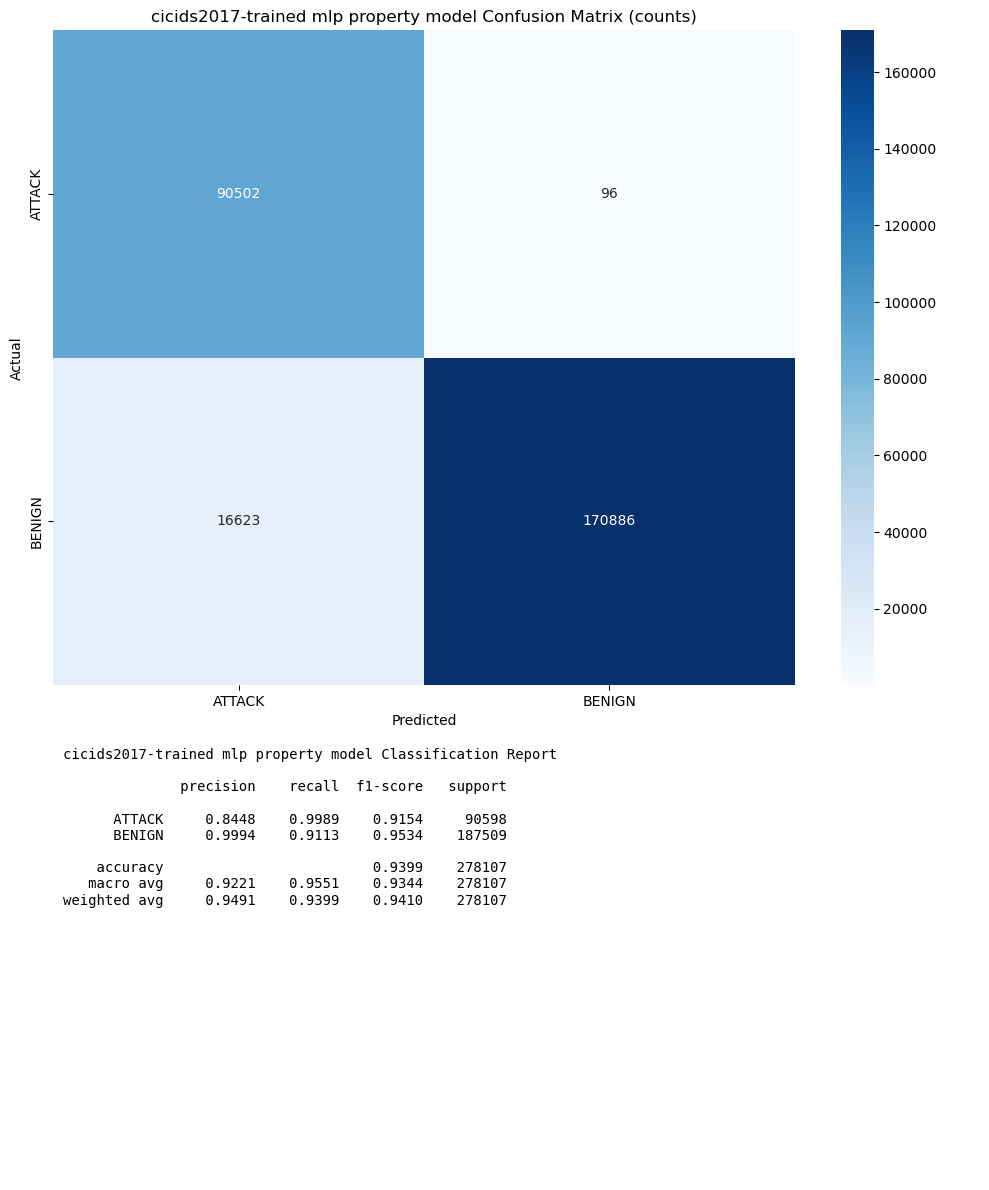

Saved model to: models/binary_DL2_2026-04-27/mlp_property_cicids2017_multi.joblib


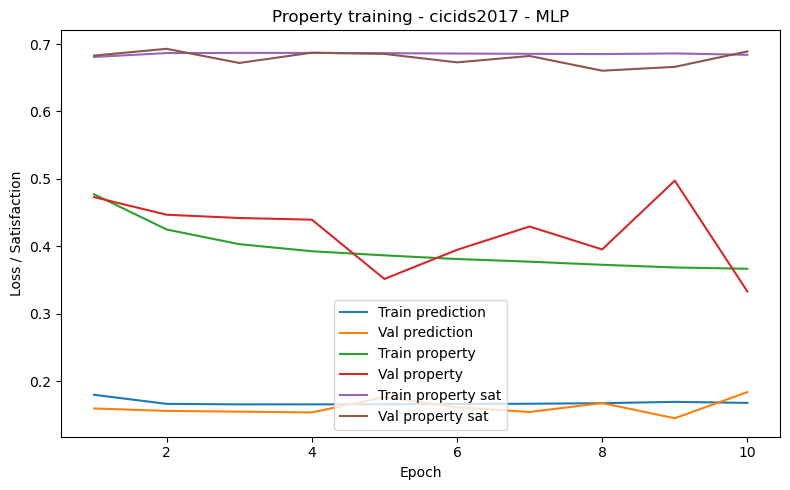


TRAINING PROPERTY MODELS ON: CICIOT2023
Train shape: (704239, 36)
label
ATTACK    361984
BENIGN    342255
Name: count, dtype: int64
Model features: 22
Property features: 35

----------------------------------------------------------------------
MLP PROPERTY MODEL ON: CICIOT2023
----------------------------------------------------------------------
Building properties for logic: DL2
Epoch 01 | train_pred_loss=0.2599 | train_prop_loss=0.5039 | train_total_loss=0.4111 | train_property_sat=0.7191 | val_pred_loss=0.2406 | val_prop_loss=0.5104 | val_total_loss=0.3937 | val_property_sat=0.7208
Train property stats | DOS_HTTP_ATTACK_loss=0.0162, DOS_HTTP_ATTACK_sat=0.9433, DOS_HTTP_ATTACK_active_frac=0.0709, DOS_HTTP_ATTACK_valid_input_frac=1.0000, DOS_HTTP_ATTACK_valid_tcp_handshake_frac=0.1122, DOS_HTTP_ATTACK_valid_http_frac=0.2894, DOS_HTTP_ATTACK_valid_duration_frac=0.9540, DOS_HTTP_ATTACK_valid_packet_size_frac=0.4052, DOS_HTTP_ATTACK_valid_iat_frac=0.8358, DOS_HTTP_ATTACK_mal_time_elap

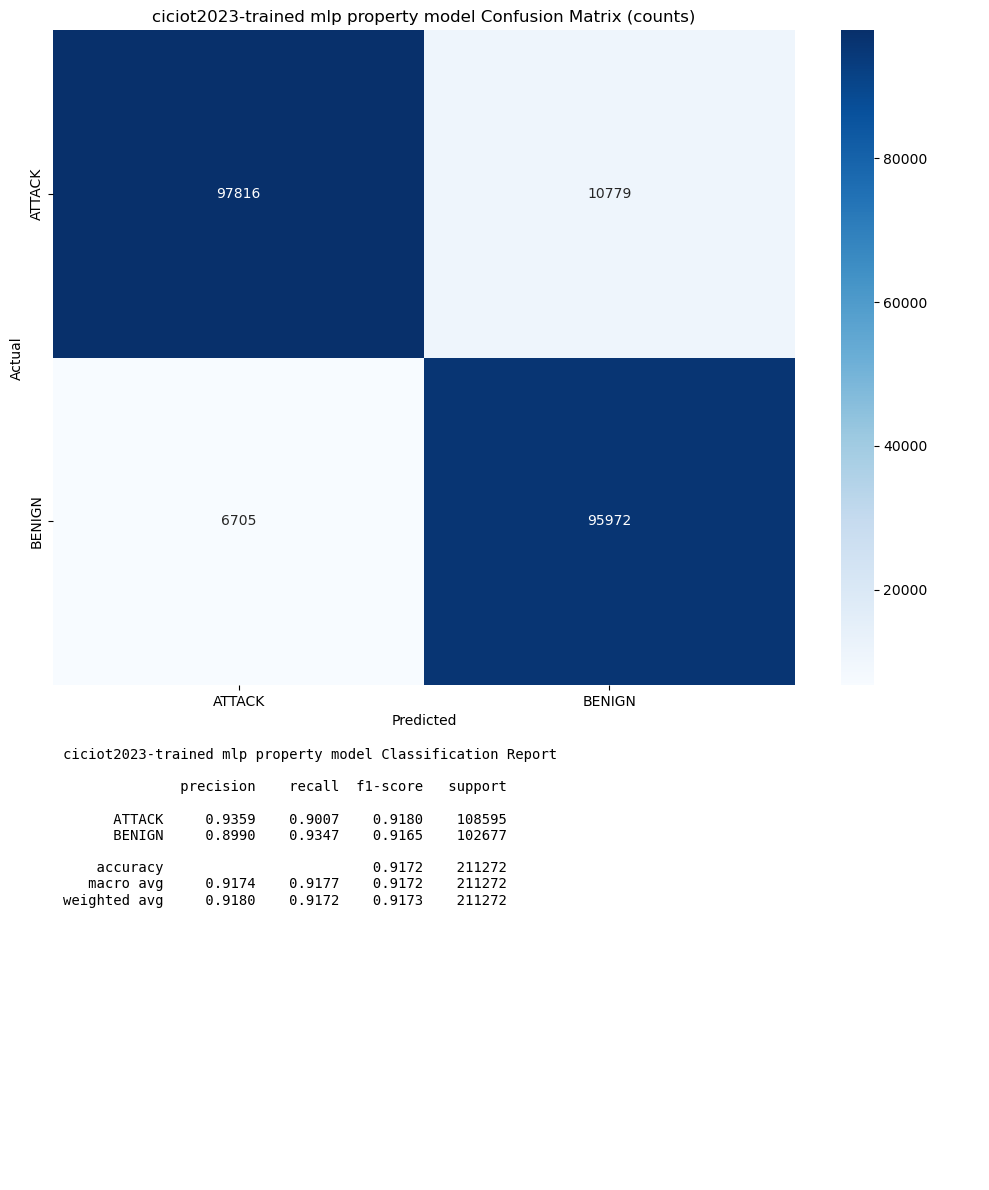

Saved model to: models/binary_DL2_2026-04-27/mlp_property_ciciot2023_multi.joblib


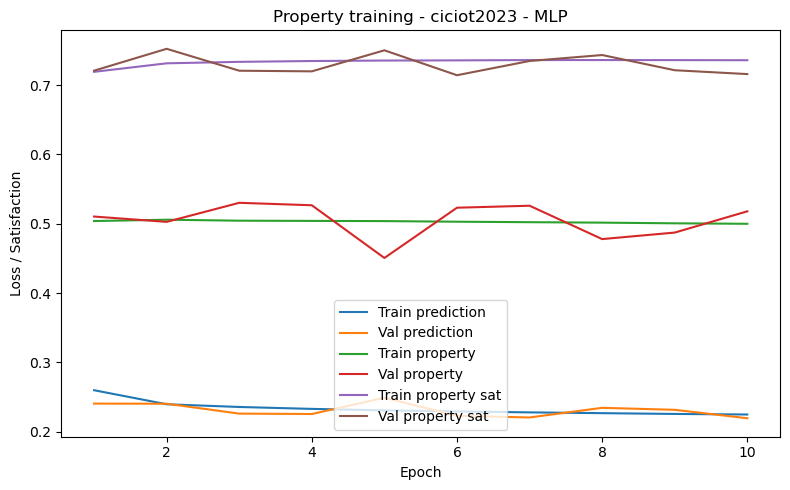

[{'dataset_name': 'cicids2017',
  'model_type': 'mlp',
  'history':    epoch  train_pred_loss  train_prop_loss  train_total_loss  \
  0      1         0.179736         0.477110          0.322869   
  1      2         0.166269         0.424894          0.293737   
  2      3         0.165540         0.403123          0.286477   
  3      4         0.165520         0.392651          0.283315   
  4      5         0.165752         0.386526          0.281710   
  5      6         0.166125         0.381126          0.280463   
  6      7         0.166452         0.377183          0.279607   
  7      8         0.167289         0.372538          0.279051   
  8      9         0.169255         0.368582          0.279829   
  9     10         0.167689         0.366626          0.277676   
  
     train_property_sat  val_pred_loss  val_prop_loss  val_total_loss  \
  0            0.680778       0.159417       0.472926        0.301295   
  1            0.686531       0.155848       0.446757      

In [33]:
run_property_experiments(
    datasets=DATASETS_BINARY,
    model_types=MODEL_TYPES,
    lambda_prop=LAMBDA_PROPS,
    learning_rate=LEARNING_RATES,
    batch_size=BATCH_SIZES,
    num_epochs=NUM_EPOCHS,
    model_name_save=f"binary_DL2_{date.today()}",
    logic=pml_logics.DL2(),
)

In [39]:
df_cicids2017_full = filter_labels(pd.concat([df_cicids2017_train_binary, df_cicids2017_test_binary]), ["BENIGN", "ATTACK"])
df_ciciot2023_full = filter_labels(pd.concat([df_ciciot2023_train_binary, df_ciciot2023_test_binary]), ["BENIGN", "ATTACK"])

In [40]:
DATASETS_EVAL = {
    "cicids2017": {"X": df_cicids2017_full[PROPERTY_FEATURES], "y": df_cicids2017_full["label"]},
    "ciciot2023": {"X": df_ciciot2023_full[PROPERTY_FEATURES], "y": df_ciciot2023_full["label"]},
}
MODEL_TYPES_EVAL = [ 
    "mlp", 
    "cnnlstm"
]

In [41]:
def load_and_evaluate_model(
    joblib_path,
    X,
    y_true,
    model_name="Model",
    device=None,
    batch_size=1024,
    path_to_save=".",
):
    joblib_object = joblib.load(joblib_path)

    model = joblib_object["model"]
    ordinal_encoder = joblib_object["ordinal_encoder"]
    scaler = joblib_object["scaler"]
    label_encoder = joblib_object["label_encoder"]

    features = joblib_object["features"]
    categorical_cols = joblib_object["categorical_cols"]

    X = X[features].copy()

    X[categorical_cols] = ordinal_encoder.transform(X[categorical_cols])

    for col in features:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    X_scaled = scaler.transform(X[features])
    X_np = X_scaled.astype(np.float32)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model.eval()

    X_tensor = torch.tensor(X_np, dtype=torch.float32).unsqueeze(1)

    preds_all = []

    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            xb = X_tensor[i:i + batch_size].to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds_all.extend(preds)

    y_pred = label_encoder.inverse_transform(np.array(preds_all))

    return evaluate_model(
        y_true,
        y_pred,
        model_name=model_name,
        path_to_save=path_to_save,
    )


EVALUATING CICIDS2017-MLP ON ciciot2023

=== CICIDS2017-MLP TESTED ON ciciot2023 Classification Report ===

              precision    recall  f1-score   support

      ATTACK     0.8558    0.5481    0.6682    470579
      BENIGN     0.6537    0.9024    0.7582    444932

    accuracy                         0.7202    915511
   macro avg     0.7548    0.7252    0.7132    915511
weighted avg     0.7576    0.7202    0.7119    915511

Overall Accuracy: 0.7202

=== Per-Label Accuracy ===

ATTACK: 0.5481
BENIGN: 0.9024


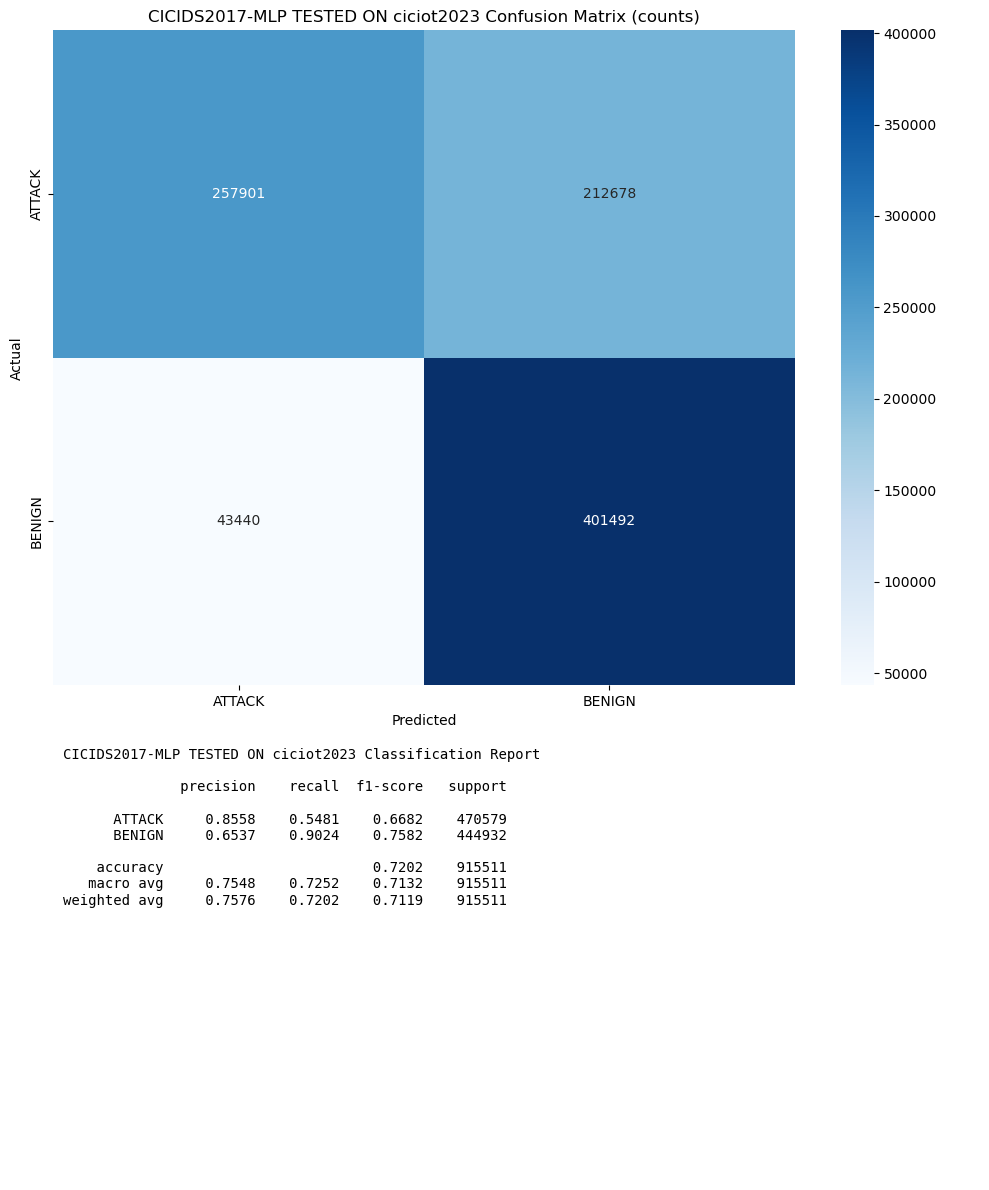


EVALUATING CICIOT2023-MLP ON cicids2017

=== CICIOT2023-MLP TESTED ON cicids2017 Classification Report ===

              precision    recall  f1-score   support

      ATTACK     0.6764    0.9816    0.8009    392591
      BENIGN     0.9886    0.7731    0.8677    812539

    accuracy                         0.8410   1205130
   macro avg     0.8325    0.8774    0.8343   1205130
weighted avg     0.8869    0.8410    0.8459   1205130

Overall Accuracy: 0.8410

=== Per-Label Accuracy ===

ATTACK: 0.9816
BENIGN: 0.7731


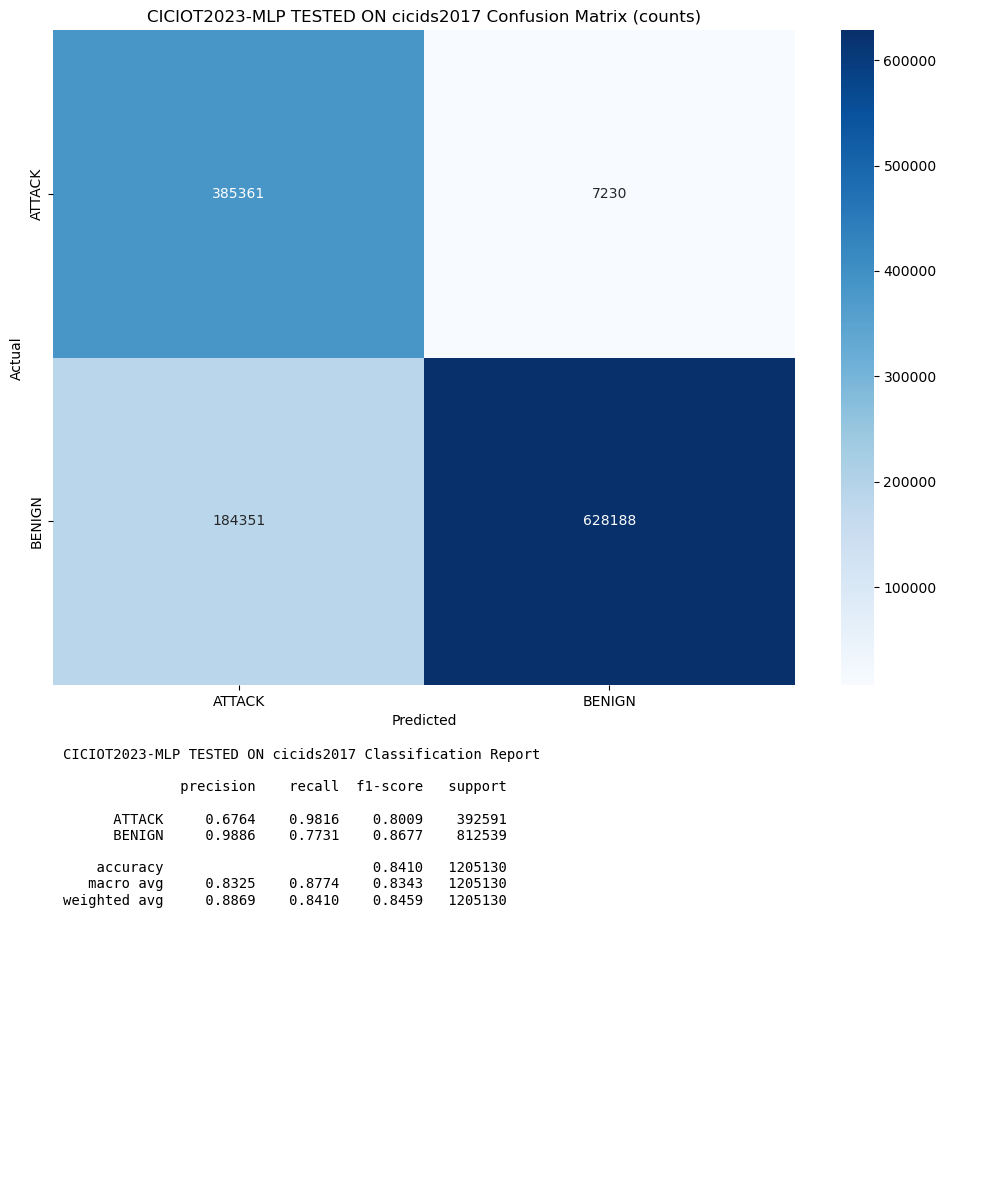

In [42]:
for MODEL_TYPE in MODEL_TYPES:
    for train_dataset in DATASETS_EVAL.keys():
        if train_dataset == "cicids2017":
            test_dataset = "ciciot2023"
        else:
            test_dataset = "cicids2017"

        X_test = DATASETS_EVAL[test_dataset]["X"]
        y_test = DATASETS_EVAL[test_dataset]["y"]
        print("\n" + "=" * 70)
        print(f"EVALUATING {train_dataset.upper()}-{MODEL_TYPE.upper()} ON {test_dataset}")
        print("=" * 70)
        joblib_path = f"models/binary_DL2_{date.today()}/{MODEL_TYPE}_property_{train_dataset}_multi.joblib"
        load_and_evaluate_model(
            joblib_path=joblib_path,
            X=X_test,
            y_true=y_test,
            model_name=f"{train_dataset.upper()}-{MODEL_TYPE.upper()} TESTED ON {test_dataset}",
            batch_size=1024,
            path_to_save=f"{date.today()}/cross_dataset_evaluation_results",
        )

### PortScan, DOS_HTTP_FLOOD

In [27]:
TARGET_LABELS = [
    "BENIGN",
    "PORTSCAN",
    "DOS_HTTP_FLOOD",
]

BATCH_SIZES = 256
NUM_EPOCHS = 1
LEARNING_RATES = 1e-3

LAMBDA_PROPS = 0.3

MODEL_TYPES = [
    "mlp",
    # "cnnlstm",
]

In [28]:
df_cicids2017_train_filtered = filter_labels(df_cicids2017_train, TARGET_LABELS)
df_cicids2017_test_filtered = filter_labels(df_cicids2017_test, TARGET_LABELS)

df_ciciot2023_train_filtered = filter_labels(df_ciciot2023_train, TARGET_LABELS)
df_ciciot2023_test_filtered = filter_labels(df_ciciot2023_test, TARGET_LABELS)

In [29]:
df_cicids2017_train_3_feats = add_property_boolean_features(
    df_cicids2017_train_filtered
)[PROPERTY_FEATURES_WITH_LABEL]

df_cicids2017_test_3_feats = add_property_boolean_features(
    df_cicids2017_test_filtered
)[PROPERTY_FEATURES_WITH_LABEL]

df_ciciot2023_train_3_feats = add_property_boolean_features(
    df_ciciot2023_train_filtered
)[PROPERTY_FEATURES_WITH_LABEL]

df_ciciot2023_test_3_feats = add_property_boolean_features(
    df_ciciot2023_test_filtered
)[PROPERTY_FEATURES_WITH_LABEL]

In [30]:
DATASETS_3_FEATS = {
    "cicids2017": {
        "data_train": df_cicids2017_train_3_feats,
        "data_test": df_cicids2017_test_3_feats,
    },
    "ciciot2023": {
        "data_train": df_ciciot2023_train_3_feats,
        "data_test": df_ciciot2023_test_3_feats,
    },
}

In [31]:
run_property_experiments()

TypeError: run_property_experiments() missing 7 required positional arguments: 'datasets', 'model_types', 'lambda_prop', 'learning_rate', 'batch_size', 'num_epochs', and 'model_name_save'

## Cross-data eval

In [ ]:
df_cicids2017_full = filter_labels(pd.concat([df_cicids2017_train_property, df_cicids2017_test_property]), TARGET_LABELS)
df_ciciot2023_full = filter_labels(pd.concat([df_ciciot2023_train_property, df_ciciot2023_test_property]), TARGET_LABELS)

In [ ]:
DATASETS_EVAL = {
    "cicids2017": {"X": df_cicids2017_full[PROPERTY_FEATURES], "y": df_cicids2017_full["label"]},
    "ciciot2023": {"X": df_ciciot2023_full[PROPERTY_FEATURES], "y": df_ciciot2023_full["label"]},
}
MODEL_TYPES_EVAL = [ 
    "mlp", 
    "cnnlstm"
]

In [ ]:
def load_and_evaluate_model(
    joblib_path,
    X,
    y_true,
    model_name="Model",
    device=None,
    batch_size=1024,
    path_to_save=".",
):
    joblib_object = joblib.load(joblib_path)

    model = joblib_object["model"]
    ordinal_encoder = joblib_object["ordinal_encoder"]
    scaler = joblib_object["scaler"]
    label_encoder = joblib_object["label_encoder"]

    features = joblib_object["features"]
    categorical_cols = joblib_object["categorical_cols"]

    X = X[features].copy()

    X[categorical_cols] = ordinal_encoder.transform(X[categorical_cols])

    for col in features:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    X_scaled = scaler.transform(X[features])
    X_np = X_scaled.astype(np.float32)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model.eval()

    X_tensor = torch.tensor(X_np, dtype=torch.float32).unsqueeze(1)

    preds_all = []

    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            xb = X_tensor[i:i + batch_size].to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            preds_all.extend(preds)

    y_pred = label_encoder.inverse_transform(np.array(preds_all))

    return evaluate_model(
        y_true,
        y_pred,
        model_name=model_name,
        path_to_save=path_to_save,
    )


EVALUATING CICIDS2017-MLP ON ciciot2023

=== CICIDS2017-MLP TESTED ON ciciot2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.6159    0.9217    0.7384    444932
DOS_HTTP_FLOOD     0.4798    0.0533    0.0959    189086
      PORTSCAN     0.8487    0.6892    0.7607    281493

      accuracy                         0.6709    915511
     macro avg     0.6481    0.5547    0.5317    915511
  weighted avg     0.6594    0.6709    0.6126    915511

Overall Accuracy: 0.6709

=== Per-Label Accuracy ===

BENIGN: 0.9217
DOS_HTTP_FLOOD: 0.0533
PORTSCAN: 0.6892


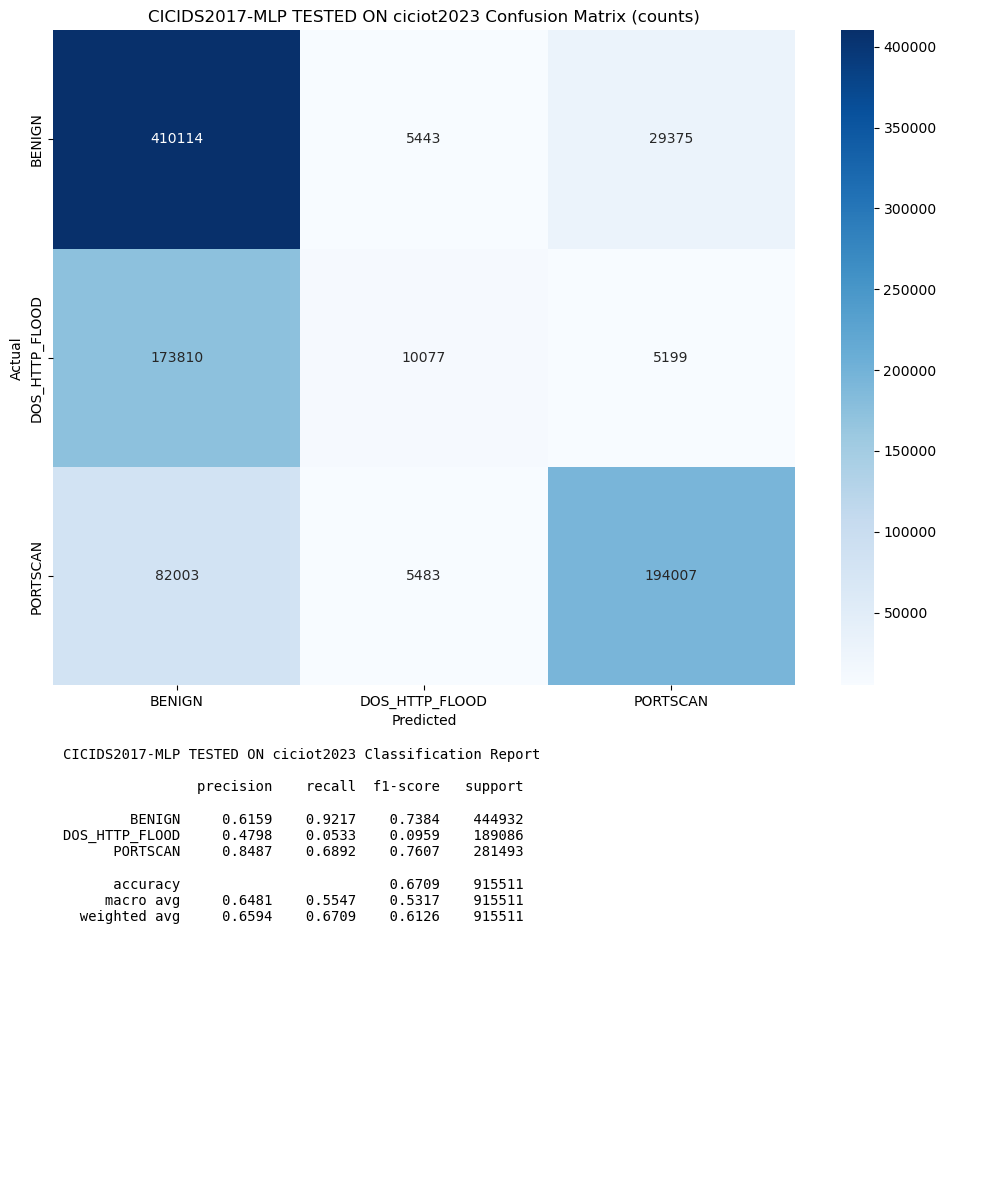


EVALUATING CICIOT2023-MLP ON cicids2017

=== CICIOT2023-MLP TESTED ON cicids2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.9410    0.7906    0.8593    812539
DOS_HTTP_FLOOD     0.5540    0.7874    0.6503    192347
      PORTSCAN     0.8019    0.9976    0.8891    200244

      accuracy                         0.8245   1205130
     macro avg     0.7656    0.8585    0.7996   1205130
  weighted avg     0.8561    0.8245    0.8309   1205130

Overall Accuracy: 0.8245

=== Per-Label Accuracy ===

BENIGN: 0.7906
DOS_HTTP_FLOOD: 0.7874
PORTSCAN: 0.9976


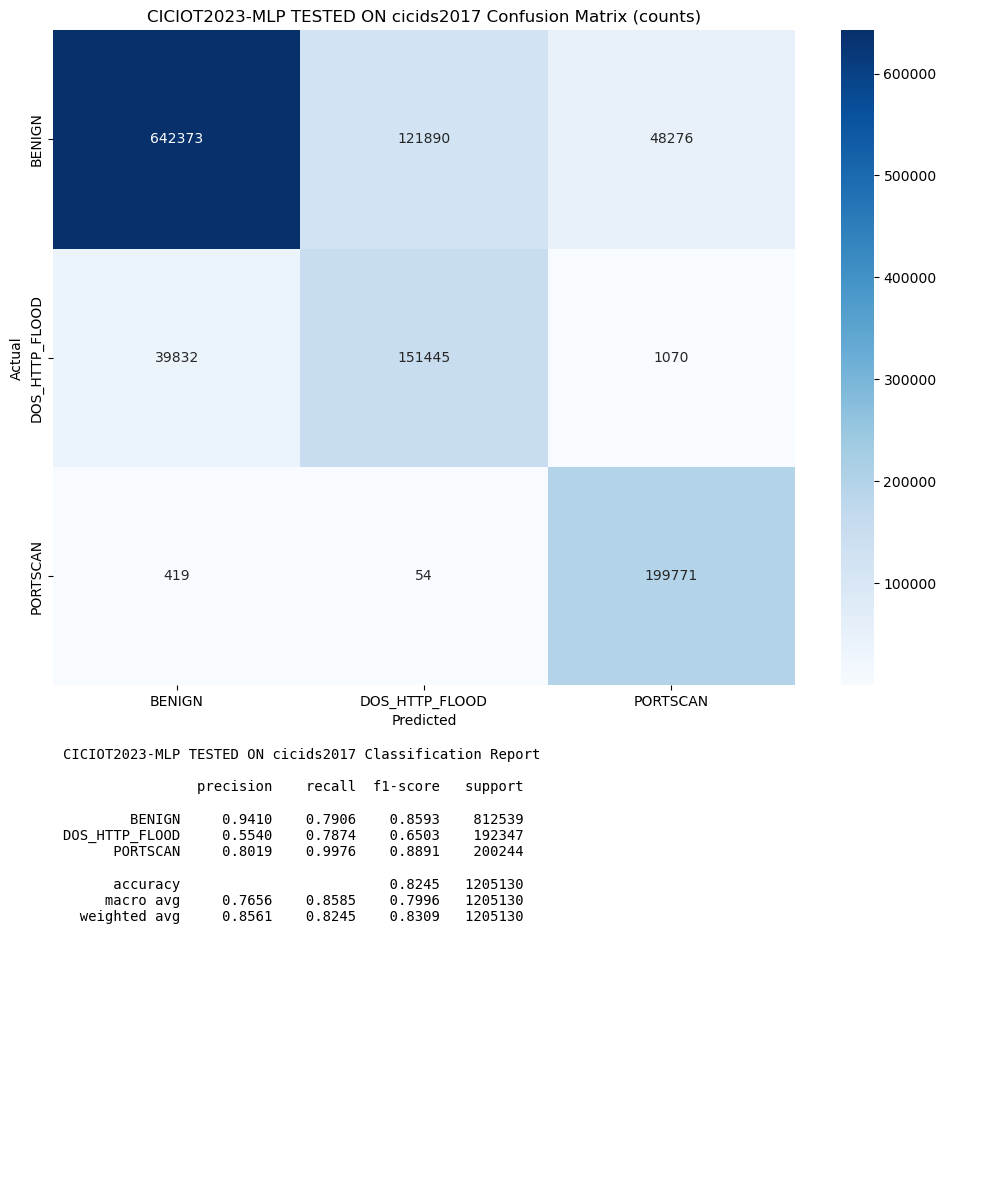

In [ ]:
for MODEL_TYPE in MODEL_TYPES:
    for train_dataset in DATASETS_EVAL.keys():
        if train_dataset == "cicids2017":
            test_dataset = "ciciot2023"
        else:
            test_dataset = "cicids2017"

        X_test = DATASETS_EVAL[test_dataset]["X"]
        y_test = DATASETS_EVAL[test_dataset]["y"]
        print("\n" + "=" * 70)
        print(f"EVALUATING {train_dataset.upper()}-{MODEL_TYPE.upper()} ON {test_dataset}")
        print("=" * 70)
        joblib_path = f"{property_output_model_dir}/{MODEL_TYPE}_property_{train_dataset}_multi.joblib"
        load_and_evaluate_model(
            joblib_path=joblib_path,
            X=X_test,
            y_true=y_test,
            model_name=f"{train_dataset.upper()}-{MODEL_TYPE.upper()} TESTED ON {test_dataset}",
            batch_size=1024,
            path_to_save=f"{date.today()}/cross_dataset_evaluation_results",
        )